
# Limit Comparisons Experiment -- Visualization

Visualize how comparison budgets impact NDCG@10 for the limit comparisons experiment stored in `../reports/limit_comparisons_experiment.csv`. The notebook builds budget curves per dataset and highlights the best budget per base ranker/oracle combo.


In [8]:

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

plt.style.use("ggplot")


In [9]:

DATA_PATH = Path("../reports/limit_comparisons_experiment.csv")
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Expected results at {DATA_PATH}")

limit_df = pd.read_csv(DATA_PATH)
limit_df.head()


,Ranker,Dataset,Comparisons,NDCG@10,Budget
0,Mohajer (IR) [Bidirectional],trec-covid,2500,0.48983,50
1,Mohajer (IR) [Bidirectional],trec-covid,5000,0.48983,100
2,Mohajer (IR) [Bidirectional],trec-covid,7500,0.48983,150
3,Mohajer (IR) [Bidirectional],trec-covid,10000,0.73588,200
4,Mohajer (IR) [Bidirectional],trec-covid,12500,0.72847,250


In [10]:

limit_df["Budget"] = limit_df["Budget"].astype(int)
limit_df["Oracle"] = limit_df["Ranker"].str.extract(r"\[(.+)\]\s*")
limit_df["BaseRanker"] = limit_df["Ranker"].str.replace(r"\s*\[.+\]\s*", "", regex=True)
limit_df = limit_df.sort_values(["Dataset", "BaseRanker", "Oracle", "Budget"]).reset_index(drop=True)

datasets = limit_df["Dataset"].unique().tolist()
budgets = sorted(limit_df["Budget"].unique())
print(f"Datasets: {datasets}")
print(f"Budgets: {budgets}")
limit_df.head()


Datasets: ['dbpedia-entity', 'fiqa', 'trec-covid']
Budgets: [np.int64(50), np.int64(100), np.int64(150), np.int64(200), np.int64(250), np.int64(300), np.int64(500)]


,Ranker,Dataset,Comparisons,NDCG@10,Budget,Oracle,BaseRanker
0,Bubble Sort (Classic) [Bidirectional],dbpedia-entity,19994,0.10372,50,Bidirectional,Bubble Sort (Classic)
1,Bubble Sort (Classic) [Bidirectional],dbpedia-entity,39944,0.10372,100,Bidirectional,Bubble Sort (Classic)
2,Bubble Sort (Classic) [Bidirectional],dbpedia-entity,59894,0.10372,150,Bidirectional,Bubble Sort (Classic)
3,Bubble Sort (Classic) [Bidirectional],dbpedia-entity,79826,0.11338,200,Bidirectional,Bubble Sort (Classic)
4,Bubble Sort (Classic) [Bidirectional],dbpedia-entity,96342,0.11384,250,Bidirectional,Bubble Sort (Classic)


In [11]:

def plot_budget_curves(dataset: str, metric: str = "NDCG@10", ylabel: str | None = None):
    ds = limit_df[limit_df["Dataset"] == dataset]
    if ds.empty:
        raise ValueError(f"No rows for dataset {dataset}")

    ylabel = ylabel or metric
    fig, ax = plt.subplots(figsize=(9, 6))
    for (base, oracle), group in ds.groupby(["BaseRanker", "Oracle"]):
        series = group.sort_values("Budget")
        label = f"{base} ({oracle})"
        ax.plot(series["Budget"], series[metric], marker="o", label=label)

    ax.set_title(f"{dataset} — {metric} by budget")
    ax.set_xlabel("Comparison budget per task")
    ax.set_ylabel(ylabel)
    ax.legend(bbox_to_anchor=(1.02, 0.5), loc="center left")
    ax.grid(True)
    fig.tight_layout()
    return ax


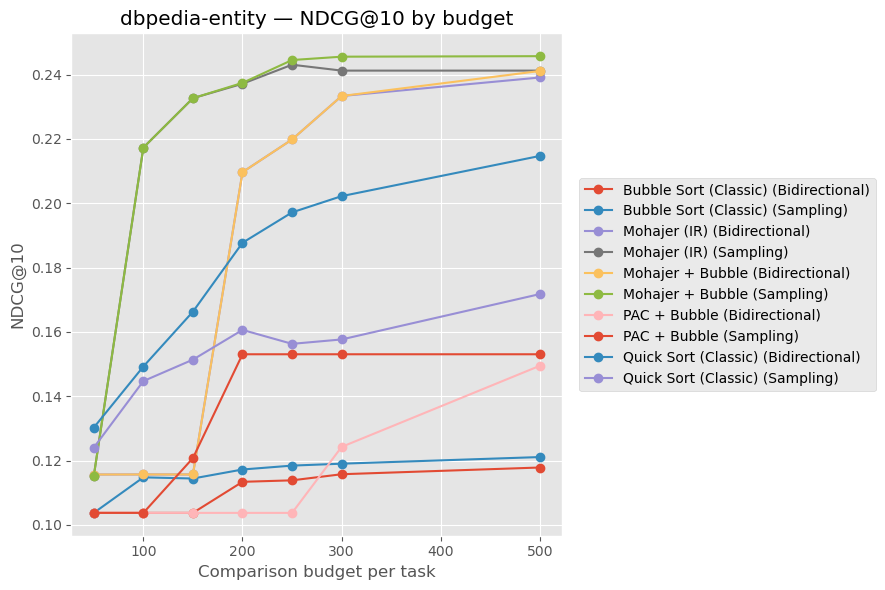

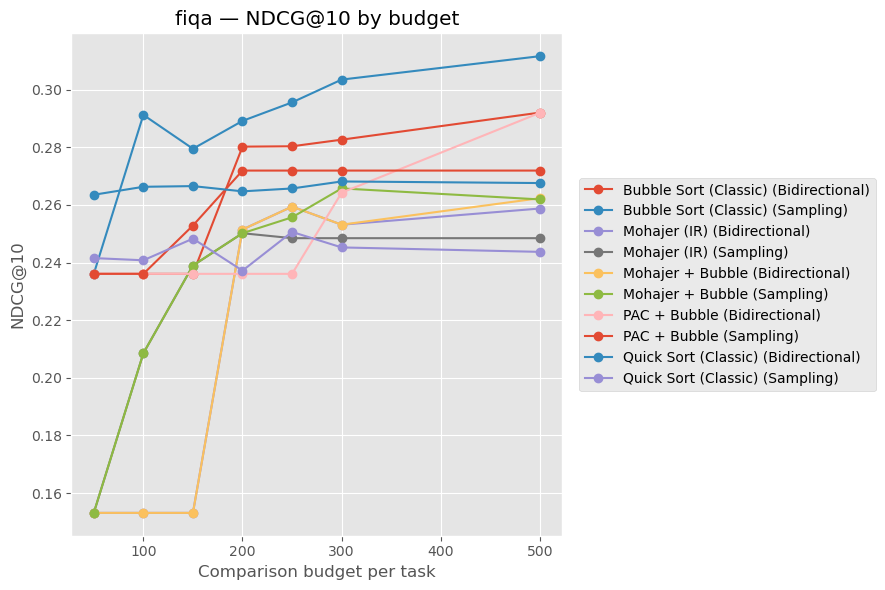

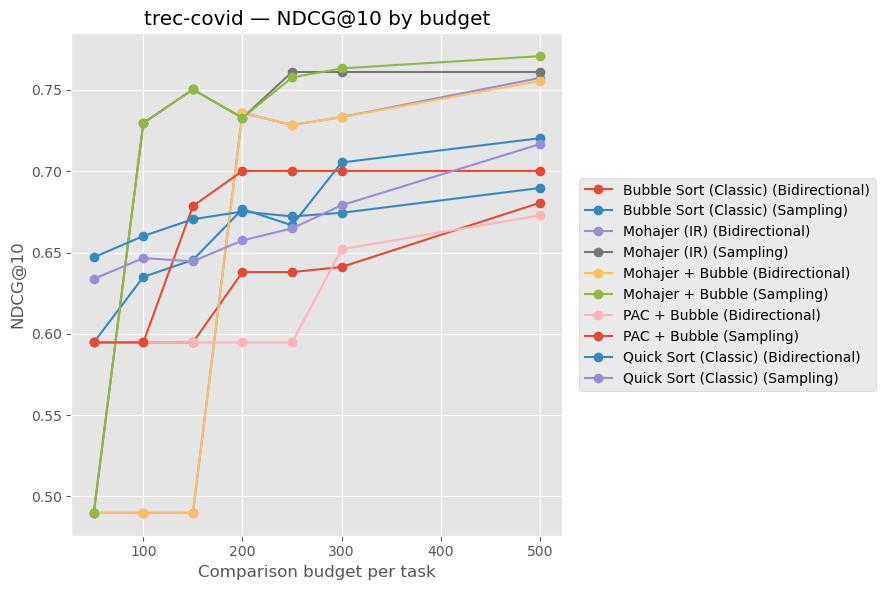

In [12]:

for dataset in datasets:
    plot_budget_curves(dataset)
plt.show()
